<a href="https://colab.research.google.com/github/Gerardo-MauricioGP/Proyecto_SAM3/blob/main/Proyecto_SAM3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!nvidia-smi

Thu Jun  4 14:09:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#Install SAM 3 and extra dependencies

In [ ]:
import torch
import torchvision
import os
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get("Proyecto_SAM3")

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())

!git clone https://github.com/facebookresearch/sam3.git
%cd sam3
!pip install -e ".[notebooks]"
%cd /content
!pip install -q supervision jupyter_bbox_widget

!pip uninstall -y cc_torch; TORCH_CUDA_ARCH_LIST="8.0 9.0"; pip install git+https://github.com/ronghanghu/cc_torch
!pip uninstall -y torch_generic_nms; TORCH_CUDA_ARCH_LIST="8.0 9.0"; pip install git+https://github.com/ronghanghu/torch_generic_nms

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
CUDA is available: True
fatal: destination path 'sam3' already exists and is not an empty directory.
/content/sam3
Obtaining file:///content/sam3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sam3 (pyproject.toml) ... done
  Created wheel for sam3: filename=sam3-0.1.0-0.editable-py3-none-any.whl size=15717 sha256=14874a43ac1e5409358b7008c7185ec2db82f928fdafa9461b2df4712dba9b8e
  Stored in directory: /tmp/pip-ephem-wheel-cache-hkz3q248/wheels/7c/90/be/80339bb9db8655024d6c9501da4e5efc6abbda4c897f5a6c43
Successfully built sam3
  Attempting uninstall: sam3
    Found existing installation: sam3 0.1.0
    Uninstalling sam3-0.1.0:
      Successfully uninstalled sam3-0.1.0
/content
  Cloning https://github.com/ronghanghu/cc_torch to /tmp/pip-req-bu

### Download example data

Downloads example videos. You can use these or replace them with your own videos.

In [ ]:
!wget -q https://storage.googleapis.com/com-roboflow-marketing/supervision/video-examples/jets-1280x720-1.mp4
!wget -q https://storage.googleapis.com/com-roboflow-marketing/supervision/video-examples/jets-1280x720-2.mp4
!wget -q https://storage.googleapis.com/com-roboflow-marketing/supervision/video-examples/jets-1280x720-3.mp4
!wget -q https://storage.googleapis.com/com-roboflow-marketing/supervision/video-examples/go-karts-1280x720-3.mp4

##Imports

In [ ]:
import cv2
import torch

import numpy as np
import supervision as sv

from pathlib import Path
from PIL import Image
from typing import Optional
from IPython.display import Video

from sam3.model_builder import build_sam3_video_predictor

HOME = Path.cwd()
print("HOME:", HOME)

###Load SAM3 model

In [ ]:
# use all available GPUs on the machine
# DEVICES = range(torch.cuda.device_count())

# # use only a single GPU
DEVICES = [torch.cuda.current_device()]

In [ ]:
predictor = build_sam3_video_predictor(bpe_path="/content/sam3/sam3/assets/bpe_simple_vocab_16e6.txt.gz", gpus_to_use=DEVICES)

INFO 2026-06-03 17:31:35,156 5906 sam3_video_predictor.py: 109: using the following GPU IDs: [0]
INFO 2026-06-03 17:31:35,158 5906 sam3_video_predictor.py: 125: 


	*** START loading model on all ranks ***


INFO 2026-06-03 17:31:35,160 5906 sam3_video_predictor.py: 127: loading model on rank=0 with world_size=1 -- this could take a while ...
INFO 2026-06-03 17:31:45,078 5906 sam3_video_base.py: 348: setting max_num_objects=10000 and num_obj_for_compile=16
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

INFO 2026-06-03 17:33:11,437 5906 sam3_video_predictor.py: 129: loading model on rank=0 with world_size=1 -- DONE locally
INFO 2026-06-03 17:33:11,438 5906 sam3_video_predictor.py: 140: 


	*** DONE loading model on all ranks ***




### Process the video

SAM 3 assumee that the video is stored as a list of JPEG frames with filenames like `<frame_index>.jpg`. Let's start by downloading a sample video, splitting it into frames, and saving them to disk. Feel free to replace `SOURCE_VIDEO` with the path to your video file.

Optimizar calidad y FPS del video para ahorrar memoria RAM

Se ajustó la configuración del video a 10fps y se disminuyó la resolución/calidad. Esto soluciona los problemas de alto consumo de RAM en la ejecución.

In [ ]:
## Comprimir video con reducción agresiva de frames y resolución
VIDEO = "/content/video_input.mov"
SOURCE_VIDEO_COMPRESSED = "/content/video_input_lowres.mov"

if os.path.exists(VIDEO):
    print(f"DEBUG: Found input video at '{VIDEO}'. Proceeding with compression.")
    # Reducimos a 10 FPS y escala de 540p para minimizar uso de RAM
    !ffmpeg -y -loglevel error -i "{VIDEO}" -vf "fps=10,scale=-2:540" -vcodec libx264 -crf 28 "{SOURCE_VIDEO_COMPRESSED}"
    if os.path.exists(SOURCE_VIDEO_COMPRESSED):
        print(" Video ultra-optimizado exitosamente.")
    else:
        print("❌ Error: Compresión de video falló. El archivo de salida no se creó. Esto puede ocurrir si ffmpeg no tiene los códecs necesarios o hay un problema con el archivo de entrada.")
else:
    print(f"❌ Error: El video de entrada '{VIDEO}' no se encontró. Asegúrate de ejecutar la celda de copia desde Drive (e7256740) antes de esta.")

DEBUG: Found input video at '/content/video_input.mov'. Proceeding with compression.
 Video ultra-optimizado exitosamente.


In [ ]:
import os

# Ruta en tu Drive
ruta_en_drive = "/content/drive/MyDrive/0601.mp4"
# Usamos un nombre sin espacios para evitar errores en los comandos de sistema
video_local = "/content/video_input.mov"

if os.path.exists(ruta_en_drive):
    print(f"🎬 Copiando video desde Drive...")
    !cp "{ruta_en_drive}" "{video_local}"
    if os.path.exists(video_local):
        print(f"✅ ¡Éxito! Video listo en: {video_local}")
    else:
        print("❌ Error crítico al copiar el archivo.")
else:
    print(f"❌ No se encontró el archivo en Drive: {ruta_en_drive}")

🎬 Copiando video desde Drive...
✅ ¡Éxito! Video listo en: /content/video_input.mov


In [ ]:
import os
from pathlib import Path

# Usamos el video comprimido para extraer los frames
SOURCE_VIDEO = Path("/content/video_input_lowres.mov")
SOURCE_FRAMES = Path("/content/video_frames")
SOURCE_FRAMES.mkdir(parents=True, exist_ok=True)

if SOURCE_VIDEO.exists():
    print(f"🎬 Extrayendo frames optimizados de: {SOURCE_VIDEO}")
    !rm -rf {SOURCE_FRAMES}/*
    # Extraemos los frames del video que ya tiene 10fps
    !ffmpeg -i "{SOURCE_VIDEO}" -q:v 2 -start_number 0 "{SOURCE_FRAMES}/%05d.jpg"
    print(f"✅ {len(os.listdir(SOURCE_FRAMES))} frames guardados en: {SOURCE_FRAMES}")
else:
    print(f"❌ Error: No se encontró el video optimizado.")

🎬 Extrayendo frames optimizados de: /content/video_input_lowres.mov
ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libt

In [ ]:
def load_frame(directory: str, index: int):
    """
    Loads a frame with a specific index from a directory where frames are named
    using the pattern '%05d.jpg' (e.g., 00000.jpg, 00001.jpg, 00002.jpg).

    Args:
        directory (str): Path to the directory containing image frames.
        index (int): Frame index (0-based).

    Returns:
        numpy.ndarray: Loaded frame in BGR format.

    Raises:
        FileNotFoundError: If the frame does not exist or cannot be read.
    """
    directory_path = Path(directory)
    frame_path = directory_path / f"{index:05d}.jpg"

    if not frame_path.exists():
        raise FileNotFoundError(f"Frame not found: {frame_path}")

    frame = cv2.imread(str(frame_path))
    if frame is None:
        raise FileNotFoundError(f"Failed to load frame: {frame_path}")

    return frame

### Opening video inference session


SAM 3 requires stateful inference for interactive video segmentation, so we need to initialize an inference session on this video. During initialization, it loads all the JPEG frames in the video directory and stores their features in the session state.

In [ ]:
import os
from pathlib import Path

# Usamos la versión optimizada para evitar que el servidor se reinicie
SOURCE_VIDEO = Path("/content/video_input_lowres.mov")

print(f"DEBUG: Checking existence of SOURCE_VIDEO: {SOURCE_VIDEO.as_posix()}")

if SOURCE_VIDEO.exists():
    try:
        print(f"🎬 Iniciando sesión con video optimizado: {SOURCE_VIDEO.name}")
        response = predictor.handle_request(
            request=dict(
                type="start_session",
                resource_path=SOURCE_VIDEO.as_posix(),
            )
        )
        session_id = response["session_id"]
        print(f"✅ Sesión iniciada exitosamente con ID: {session_id}")
    except Exception as e:
        print(f"❌ Error al iniciar sesión: {e}")
        session_id = None
else:
    print(f"❌ Error: No se encontró el video optimizado en {SOURCE_VIDEO.as_posix()}. Ejecuta la celda de compresión primero.")
    session_id = None

DEBUG: Checking existence of SOURCE_VIDEO: /content/video_input_lowres.mov
🎬 Iniciando sesión con video optimizado: video_input_lowres.mov


frame loading (OpenCV) [rank=0]: 100%|██████████| 206/206 [00:01<00:00, 159.10it/s]
INFO 2026-06-03 17:35:18,365 5906 sam3_base_predictor.py: 146: started new session 18b5f60c-fd6c-449d-a9ee-d432cd62312f


✅ Sesión iniciada exitosamente con ID: 18b5f60c-fd6c-449d-a9ee-d432cd62312f


In [ ]:
_ = predictor.handle_request(
    request=dict(
        type="reset_session",
        session_id=session_id,
    )
)

### Liberar VRAM (memoria de la GPU)

Para intentar liberar memoria de la GPU y evitar errores de `OutOfMemoryError`, puedes ejecutar el siguiente comando. Es buena práctica hacerlo antes de operaciones que sabes que consumen mucha memoria.

In [ ]:
import torch

# Libera la caché de la GPU
torch.cuda.empty_cache()
print('✅ VRAM liberada.')


✅ VRAM liberada.


### Adding a text prompt

Here we use the text prompt "person" to detect all people in the video. SAM 3 will automatically identify multiple person instances and assign each a unique object ID.

✅ Frame 0 cargado correctamente.


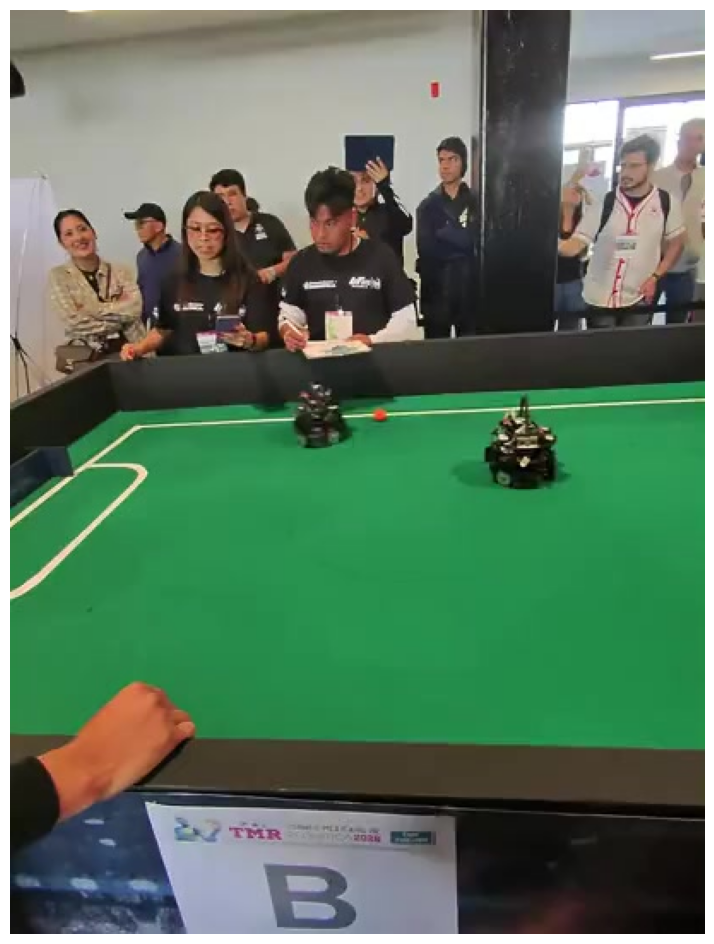

In [ ]:
import cv2
import supervision as sv
from pathlib import Path

def load_frame(directory: str, index: int):
    directory_path = Path(directory)
    frame_path = directory_path / f"{index:05d}.jpg"
    if not frame_path.exists():
        raise FileNotFoundError(f"No se encontró el frame: {frame_path}")
    frame = cv2.imread(str(frame_path))
    return frame

try:
    frame_idx = 0
    # SOURCE_FRAMES se definió en la celda
    frame = load_frame(SOURCE_FRAMES, frame_idx)
    print(f"✅ Frame {frame_idx} cargado correctamente.")
    sv.plot_image(frame)
except Exception as e:
    print(f"❌ Error al cargar frame: {e}")
    print("Asegúrate de que la celda de extracción de frames (rve0HGsg4gfp) se ejecutó con éxito.")

def from_sam(result: dict) -> sv.Detections:
    return sv.Detections(
        xyxy=sv.mask_to_xyxy(result["out_binary_masks"]),
        mask=result["out_binary_masks"],
        confidence=result["out_probs"],
        tracker_id=result["out_obj_ids"],
    )

COLOR = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff8080", "#ff66b2", "#ff66ff", "#b266ff",
    "#9999ff", "#3399ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

from typing import Optional, List

def annotate(image: np.ndarray, detections: sv.Detections, labels: Optional[List[str]] = None) -> np.ndarray:
    h, w, _ = image.shape
    text_scale = sv.calculate_optimal_text_scale(resolution_wh=(w, h))

    mask_annotator = sv.MaskAnnotator(
        color=COLOR,
        color_lookup=sv.ColorLookup.TRACK,
        opacity=0.6
    )

    annotated_image = image.copy()
    annotated_image = mask_annotator.annotate(annotated_image, detections)

    label_text_content = []
    if labels and len(labels) == len(detections.tracker_id):
        # Si se proporcionan etiquetas y coinciden en número con los objetos detectados,
        # las usamos directamente.
        for i, tracker_id in enumerate(detections.tracker_id):
            label_text_content.append(f"#{tracker_id} {labels[i]}")
    else:
        # Si no hay etiquetas o no coinciden, mostramos solo el ID del rastreador.
        for tracker_id in detections.tracker_id:
            label_text_content.append(f"#{tracker_id}")

    if label_text_content:
        label_annotator = sv.LabelAnnotator(
            color=COLOR,
            color_lookup=sv.ColorLookup.TRACK,
            text_scale=text_scale,
            text_color=sv.Color.BLACK,
            text_position=sv.Position.TOP_CENTER,
            text_offset=(0, -30)
        )
        annotated_image = label_annotator.annotate(annotated_image, detections, label_text_content)

    return annotated_image

#Divide y Vencerás

###  Fase 1: Rastreo Aislado de Robots (Estrategia "Divide y Vencerás")

En esta fase definimos el motor de propagación de video y lo aplicamos **exclusivamente a los robots** para evitar colisiones en la memoria de SAM 3.

**Proceso:**
1. **Limpieza (`reset_session`):** Borramos la memoria de la IA para iniciar en blanco.
2. **Fijación del objetivo (`add_prompt`):** Instruimos al modelo buscar "robot" en el fotograma 0.
3. **Propagación:** Hacemos el *tracking* a lo largo de todo el video y guardamos el historial de forma aislada en la variable `frame_outputs_robots`.

In [ ]:
# --- DEFINICIÓN DE LA FUNCIÓN (Para que Colab la recuerde) ---
def propagate_in_video(predictor, session_id):
    frame_outputs = {}
    for response in predictor.handle_stream_request(
        request=dict(
            type="propagate_in_video",
            session_id=session_id,
        )
    ):
        frame_outputs[response["frame_index"]] = response["outputs"]
    return frame_outputs

# --- CELDA 1: RASTREO DE ROBOTS ---
print("🤖 INICIANDO RASTREO DE ROBOTS...")

# 1. Reiniciamos la sesión para limpiar la memoria
predictor.handle_request(request=dict(type="reset_session", session_id=session_id))

# 2. Buscamos solo robots en el primer frame
predictor.handle_request(
    request=dict(type="add_prompt", session_id=session_id, frame_index=0, text="robot")
)

# 3. Propagamos en todo el video y GUARDAMOS el resultado en una variable exclusiva
frame_outputs_robots = propagate_in_video(predictor=predictor, session_id=session_id)

print(f"✅ Recorrido de los robots guardado en memoria.")


🤖 INICIANDO RASTREO DE ROBOTS...


propagate_in_video:   0%|          | 0/206 [00:00<?, ?it/s]

propagate_in_video: 0it [00:00, ?it/s]

INFO 2026-06-03 18:03:26,151 5906 sam3_base_predictor.py: 305: propagation ended in session 18b5f60c-fd6c-449d-a9ee-d432cd62312f


✅ Recorrido de los robots guardado en memoria.


###  Fase 2: Rastreo Aislado del Balón

Continuando con la estrategia, ahora procesamos la pelota de forma independiente. El paso más crítico aquí es borrar la memoria previa para evitar que SAM colapse al intentar mantener los IDs de los robots y del balón al mismo tiempo.

**Proceso:**
1. **Amnesia Estratégica (`reset_session`):** Borramos el registro de los robots de la memoria de la IA.
2. **Nuevo Objetivo (`add_prompt`):** Instruimos al modelo buscar "ball" en el fotograma 0.
3. **Almacenamiento Aislado:** Hacemos el *tracking* y guardamos este nuevo recorrido en una libreta distinta llamada `frame_outputs_ball`.

In [ ]:
print("⚽ INICIANDO RASTREO DEL BALÓN...")

# 1. Reiniciamos la sesión de nuevo (borramos a los robots de la mente de SAM)
predictor.handle_request(request=dict(type="reset_session", session_id=session_id))

# 2. Buscamos solo el balón
predictor.handle_request(
    request=dict(type="add_prompt", session_id=session_id, frame_index=0, text="ball")
)

# 3. Propagamos y GUARDAMOS en otra variable distinta
frame_outputs_ball = propagate_in_video(predictor=predictor, session_id=session_id)

print(f"✅ Recorrido del balón guardado en memoria.")

⚽ INICIANDO RASTREO DEL BALÓN...


propagate_in_video:   0%|          | 0/206 [00:00<?, ?it/s]

propagate_in_video: 0it [00:00, ?it/s]

INFO 2026-06-03 18:19:21,297 5906 sam3_base_predictor.py: 305: propagation ended in session 18b5f60c-fd6c-449d-a9ee-d432cd62312f


✅ Recorrido del balón guardado en memoria.


#Pruba y error

In [ ]:
import math
import cv2
import numpy as np
import supervision as sv

# --- 🧠 ESTADO GLOBAL DEL MARCADOR ---
# Diccionario para guardar cuántos toques lleva cada robot
marcadores = {}
# Memoria a corto plazo para evitar contar el mismo toque en fotogramas consecutivos
tocando_en_frame_anterior = set()

def callback(frame: np.ndarray, index: int) -> np.ndarray:
    global tocando_en_frame_anterior # Permite modificar la memoria entre fotogramas

    annotated_frame = frame.copy()

    robots_boxes = []
    robots_ids = []
    ball_center = None

    # --- PASO A: EXTRAER Y DIBUJAR ROBOTS ---
    if index in frame_outputs_robots:
        out_r = frame_outputs_robots[index]
        det_robots = from_sam(out_r)

        if len(det_robots) > 0:
            robots_boxes = det_robots.xyxy
            robots_ids = det_robots.tracker_id

            # Si vemos un robot nuevo, lo agregamos al marcador con 0 toques
            for r_id in robots_ids:
                if r_id not in marcadores:
                    marcadores[r_id] = 0

            labels_r = [f"Robot #{t_id}" for t_id in det_robots.tracker_id]
            annotated_frame = mask_annotator.annotate(scene=annotated_frame, detections=det_robots)
            annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=det_robots, labels=labels_r)

    # --- PASO B: EXTRAER Y DIBUJAR EL BALÓN ---
    if index in frame_outputs_ball:
        out_b = frame_outputs_ball[index]
        det_ball = from_sam(out_b)

        if len(det_ball) > 0:
            bx1, by1, bx2, by2 = det_ball.xyxy[0]
            ball_center = ((bx1 + bx2) / 2, (by1 + by2) / 2)

            det_ball.tracker_id = np.array([20] * len(det_ball.tracker_id))
            labels_b = [f"Ball" for _ in det_ball.tracker_id]

            annotated_frame = mask_annotator.annotate(scene=annotated_frame, detections=det_ball)
            annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=det_ball, labels=labels_b)

    # --- PASO C: LÓGICA DE COLISIÓN (HITBOXES) ---
    tocando_ahora = set() # Quiénes están tocando el balón en ESTE frame

    if ball_center is not None and len(robots_boxes) > 0:
        margen = 10 # Sensibilidad del toque (en píxeles)

        for i, (rx1, ry1, rx2, ry2) in enumerate(robots_boxes):
            if (rx1 - margen <= ball_center[0] <= rx2 + margen) and \
               (ry1 - margen <= ball_center[1] <= ry2 + margen):

                robot_id = robots_ids[i]
                tocando_ahora.add(robot_id)

                # LA MAGIA ANTISPAM: Si lo toca ahora, pero NO lo tocaba hace un milisegundo...
                if robot_id not in tocando_en_frame_anterior:
                    marcadores[robot_id] += 1 # ...entonces es un toque legítimo
                    print(f"⚽ ¡Toque de Robot #{robot_id}! (Lleva {marcadores[robot_id]})")

    # Actualizamos la memoria para el siguiente fotograma
    tocando_en_frame_anterior = tocando_ahora

    # --- PASO D: DIBUJAR LA TABLITA (MARCADOR UI) ---
    # Solo dibujamos la tabla si ya detectamos al menos un robot
    if len(marcadores) > 0:
        # 1. Dibujar el fondo negro del panel superior izquierdo
        x_base, y_base = 20, 20
        ancho_rect = 250
        alto_rect = 40 + (len(marcadores) * 35) # La tabla crece si hay más robots

        cv2.rectangle(annotated_frame, (10, 10), (10 + ancho_rect, 10 + alto_rect), (0, 0, 0), -1)

        # 2. Escribir el título del panel
        cv2.putText(annotated_frame, "MARCADOR DE TOQUES", (x_base, y_base + 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

        # 3. Imprimir el puntaje de cada robot
        y_text = y_base + 55
        for r_id, conteo in sorted(marcadores.items()):
            texto = f"> Robot #{r_id}: {conteo}"
            # Usamos texto amarillo para que resalte
            cv2.putText(annotated_frame, texto, (x_base, y_text),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
            y_text += 35 # Bajamos el renglón para el siguiente robot

    return annotated_frame

# --- RENDERIZADO DEL VIDEO ---
print("🎬 Generando video final con marcador incluido...")
sv.process_video(
    source_path=SOURCE_VIDEO,
    target_path=TARGET_VIDEO,
    callback=callback
)

print("⚙️ Optimizando para visualización web...")
!ffmpeg -y -loglevel error -i "{TARGET_VIDEO}" -c:v libx264 -pix_fmt yuv420p -profile:v main -level 3.1 -movflags +faststart "{TARGET_VIDEO_COMPRESSED}"
print(f"✅ Video listo: {TARGET_VIDEO_COMPRESSED}")


🎬 Generando video final con marcador incluido...
⚽ ¡Toque de Robot #1! (Lleva 1)
⚽ ¡Toque de Robot #0! (Lleva 1)
⚽ ¡Toque de Robot #1! (Lleva 2)
⚽ ¡Toque de Robot #0! (Lleva 2)
⚽ ¡Toque de Robot #1! (Lleva 3)
⚽ ¡Toque de Robot #1! (Lleva 4)
⚽ ¡Toque de Robot #1! (Lleva 5)
⚽ ¡Toque de Robot #1! (Lleva 6)
⚽ ¡Toque de Robot #1! (Lleva 7)
⚽ ¡Toque de Robot #1! (Lleva 8)
⚽ ¡Toque de Robot #1! (Lleva 9)
⚽ ¡Toque de Robot #0! (Lleva 3)
⚽ ¡Toque de Robot #1! (Lleva 10)
⚽ ¡Toque de Robot #0! (Lleva 4)
⚽ ¡Toque de Robot #1! (Lleva 11)
⚽ ¡Toque de Robot #0! (Lleva 5)
⚽ ¡Toque de Robot #1! (Lleva 12)
⚽ ¡Toque de Robot #1! (Lleva 13)
⚽ ¡Toque de Robot #1! (Lleva 14)
⚽ ¡Toque de Robot #0! (Lleva 6)
⚽ ¡Toque de Robot #0! (Lleva 7)
⚙️ Optimizando para visualización web...
✅ Video listo: /content/video_input_lowres-tracked-web.mp4


In [ ]:
TARGET_VIDEO = HOME / f"{SOURCE_VIDEO.stem}-tracked.mov"
TARGET_VIDEO_COMPRESSED = HOME / f"{TARGET_VIDEO.stem}-web.mp4"

# Preparamos las herramientas de dibujo
mask_annotator = sv.MaskAnnotator(color=COLOR, color_lookup=sv.ColorLookup.TRACK)
label_annotator = sv.LabelAnnotator(
    color=COLOR, color_lookup=sv.ColorLookup.TRACK, text_color=sv.Color.BLACK
)

def callback(frame: np.ndarray, index: int) -> np.ndarray:
    annotated_frame = frame.copy()

    # --- PASO A: DIBUJAR LOS ROBOTS ---
    if index in frame_outputs_robots:
        out_r = frame_outputs_robots[index]
        det_robots = from_sam(out_r)

        if len(det_robots) > 0:
            labels_r = [f"Robot #{t_id}" for t_id in det_robots.tracker_id]
            annotated_frame = mask_annotator.annotate(scene=annotated_frame, detections=det_robots)
            annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=det_robots, labels=labels_r)

    # --- PASO B: DIBUJAR EL BALÓN ---
    if index in frame_outputs_ball:
        out_b = frame_outputs_ball[index]
        det_ball = from_sam(out_b)

        if len(det_ball) > 0:
            # Forzamos el ID a 20 para que Supervision le asigne un color distinto al de los robots
            det_ball.tracker_id = np.array([20] * len(det_ball.tracker_id))
            labels_b = ["Ball"] * len(det_ball.tracker_id)

            annotated_frame = mask_annotator.annotate(scene=annotated_frame, detections=det_ball)
            annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=det_ball, labels=labels_b)

    return annotated_frame

print("🎬 Generando video final uniendo Robots y Balón...")
sv.process_video(
    source_path=SOURCE_VIDEO,
    target_path=TARGET_VIDEO,
    callback=callback
)

print("⚙️ Optimizando para visualización web...")
!ffmpeg -y -loglevel error -i "{TARGET_VIDEO}" -c:v libx264 -pix_fmt yuv420p -profile:v main -level 3.1 -movflags +faststart "{TARGET_VIDEO_COMPRESSED}"
print(f"✅ Video listo: {TARGET_VIDEO_COMPRESSED}")



🎬 Generando video final uniendo Robots y Balón...
⚙️ Optimizando para visualización web...
✅ Video listo: /content/video_input_lowres-tracked-web.mp4


In [ ]:
from IPython.display import HTML
from base64 import b64encode
import os

if os.path.exists(str(TARGET_VIDEO_COMPRESSED)):
    video_file = open(str(TARGET_VIDEO_COMPRESSED), 'rb').read()
    video_url = 'data:video/mp4;base64,' + b64encode(video_file).decode()

    display(HTML(f'''
    <h3>Video Resultante</h3>
    <video width="640" height="480" controls>
          <source src="{video_url}" type="video/mp4">
          Tu navegador no soporta el video.
    </video>
    <br>
    <a href="{video_url}" download="resultado_seguimiento.mp4" style="color: #007bff; font-weight: bold;">Click aquí para descargar el video si no carga</a>
    '''))
else:
    print("❌ El video procesado no se encontró. Asegúrate de ejecutar la celda anterior.")